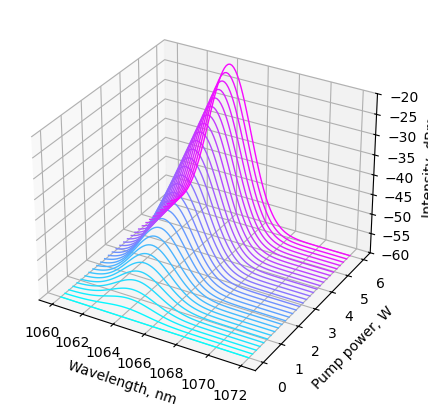

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Создаем фигуру и 3D-оси
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')

# Генерируем тестовые данные
wavelengths = np.linspace(1060, 1072, 100)  # Ось X
pump_powers = np.linspace(0, 6, 30)         # Ось Y

# Рисуем каждую линию отдельно
for i, power in enumerate(pump_powers):
    # Моделируем спектр (например, гауссиана, которая меняется от мощности)
    intensity_dbm = -60 + 40 * np.exp(-((wavelengths - 1064) / 2)**2) * (power / 6)
    
    # Повторяем значение мощности для всей линии по оси Y
    y_coords = np.full_like(wavelengths, power)
    
    # Цвет линии можно менять в зависимости от мощности (эффект градиента)
    color = plt.cm.cool(i / len(pump_powers)) 
    
    ax.plot(wavelengths, y_coords, intensity_dbm, color=color, linewidth=1)

# Настройка осей (как на вашем рисунке)
ax.set_xlabel('Wavelength, nm')
ax.set_ylabel('Pump power, W')
ax.set_zlabel('Intensity, dBm')
ax.set_zlim(-60, -20)

plt.show()


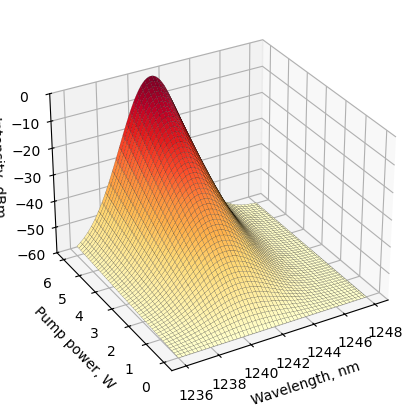

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')

# Создаем двумерную сетку координат (Meshgrid)
wavelengths = np.linspace(1236, 1248, 100)
pump_powers = np.linspace(0, 6, 50)
X, Y = np.meshgrid(wavelengths, pump_powers)

# Генерируем матрицу интенсивностей Z
Z = -60 + 60 * np.exp(-((X - 1241) / 3)**2) * (Y / 6)

# Строим поверхность с цветовой картой 'YlOrRd' (желто-оранжево-красный, как на графике b)
surf = ax.plot_surface(X, Y, Z, cmap='YlOrRd', edgecolor='black', linewidth=0.1)

ax.set_xlabel('Wavelength, nm')
ax.set_ylabel('Pump power, W')
ax.set_zlabel('Intensity, dBm')
ax.set_zlim(-60, 0)

# Меняем угол обзора, чтобы было как на картинке
ax.view_init(elev=30, azim=-120)

plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime
import os
from tqdm import tqdm

from scripts.read_txt_file import read_txt_xy
# plot_waterfall больше не импортируем, строим график прямо здесь
from scripts.convert_dBm_mW import convert_dbm_to_mw
from scripts.plot_xy import plot_xy_markers
from scripts.write_data_txt import write_txt_xy
from scripts.plot_multiple_curves import plot_multiple_curves
from scripts.get_formated_time import get_formatted_time

LINEWIDTHS = [2]
CURRENT = 9.83

WAVELENGTH_START = 1056
WAVELENGTH_STOP = 1071  # Последний элемент не включается
WAVELENGTH_STEP = 1
WAVELENGTHS = np.arange(WAVELENGTH_START, WAVELENGTH_STOP, WAVELENGTH_STEP)

NUMBER_ITERATIONS = 40
MEGA = 1e+6
ITERATION_LABEL = "Iteration (N)"
FREQ_LABEL_MHz = 'Frequency (MHz)'
WAVE_LABEL = 'Wavelength (nm)'
POW_LABEL_mW = 'Power (mW)'  # Изменили на mW, так как у вас идет конвертация
time_now = get_formatted_time()

WAVE_START = 1050
WAVE_STOP = 1060
POW_START = -55
# Папка, где лежат данные   
DATA_FOLDER = rf'C:\Users\namys\Documents\DATA_dual_wavelength_laser\LD_set_current_9.83A_September-13-2026_time_10-18-08'

for linewidth in LINEWIDTHS:
    SAVE_FOLDER = rf'{DATA_FOLDER}\OSA_graphs_{time_now}\linewidth_{linewidth}nm'
    
    # Создаем папку для сохранения, если её еще нет
    if not os.path.exists(SAVE_FOLDER):
        os.makedirs(SAVE_FOLDER)
       
    for wavelength in tqdm(WAVELENGTHS, desc=f"Processing LW {linewidth}nm"):
        pow_arr_arr = []
        sub_wave_arr = None
        
        # 1. Собираем данные по всем итерациям
        for iteration in range(1, 41):
            osa_txt_file = rf"C:\Users\namys\Documents\DATA_dual_wavelength_laser\LD_set_current_9.83A_September-13-2026_time_10-18-08\OSA\linewidth_{linewidth}nm\wavelength_{wavelength}nm\osa_iteration_{iteration}_wavelength_{wavelength}nm_linewidth_{linewidth}nm_current_9.83A.txt"
            
            if not os.path.exists(osa_txt_file):
                continue
                
            wave_arr, pow_arr = read_txt_xy(path=osa_txt_file)
            
            # Перевод на линейный масштаб (дБм -> мВт)
            pow_arr = convert_dbm_to_mw(pow_arr_dbm=pow_arr)
            
            # Создаем маску для диапазона длин волн
            mask_freq = (wave_arr >= WAVE_START) & (wave_arr <= WAVE_STOP)
            
            # Фильтруем массивы
            sub_wave_arr = wave_arr[mask_freq]
            sub_pow_arr = pow_arr[mask_freq]
            
            pow_arr_arr.append(sub_pow_arr)
            
        # Проверяем, удалось ли собрать данные
        if not pow_arr_arr or sub_wave_arr is None:
            print(f"Данные для wavelength {wavelength}nm не найдены.")
            continue
            
        # 2. Подготовка данных для честной 3D поверхности (plot_surface)
        # Превращаем список массивов в двумерную матрицу Z (размерность: Кол-во итераций x Длина спектра)
        Z = np.array(pow_arr_arr) 
        
        # Создаем сетку координат X (Длины волн) и Y (Итерации)
        iterations = np.arange(1, len(pow_arr_arr) + 1)
        X, Y = np.meshgrid(sub_wave_arr, iterations)
        
        # 3. Построение 3D графика
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        
        # Рисуем сплошную поверхность. 
        # cmap='jet' даст сине-голубой-красный градиент. Для теплого (как на рис. b) используйте 'YlOrRd' или 'plasma'
        surf = ax.plot_surface(X, Y, Z, cmap='jet', edgecolor='black', linewidth=0.1, antialiased=True)
        
        # Добавляем цветовую шкалу сбоку (опционально)
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
        
        # Настройка подписей осей
        ax.set_xlabel(WAVE_LABEL, labelpad=10)
        ax.set_ylabel(ITERATION_LABEL, labelpad=10)
        ax.set_zlabel(POW_LABEL_mW, labelpad=10)
        
        # Настройка углов обзора (как вы задавали: elev=30, azim=45)
        ax.view_init(elev=30, azim=45)
        
        # Сетка и красивый заголовок
        ax.grid(True)
        plt.title(f"3D Spectrum: LW {linewidth}nm, Center WL {wavelength}nm")
        
        # Автоматическое сохранение графика в папку SAVE_FOLDER
        save_filename = f"3D_surface_WL_{wavelength}nm_LW_{linewidth}nm.png"
        plt.savefig(os.path.join(SAVE_FOLDER, save_filename), dpi=300, bbox_inches='tight')
        
        # Вывод на экран
        plt.show()
        plt.close()  # Закрываем фигуру, чтобы не забивать оперативную память в цикле


ModuleNotFoundError: No module named 'scripts.read_txt_file'